# Data Unterstanding - Olist Marketplace

## Zweck
Dieses Notebook dokumentiert Struktur, Beziehungen und Datenqualität der Rohdaten.

Ziel ist es zu prüfen, ob der Datensatz für eine Analyse geeignet ist.
Es werden keine Transformationen, Features oder Business-Interpretationen vorgenommen.

In [2]:
import duckdb
from pathlib import Path

# Verbindung zur DuckDB (in-memory reicht völlig)
con = duckdb.connect()

# Hilfsfunktion für SQL-Abfragen
def sql(q):
    return con.sql(q).df()

# Projektpfad bestimmen (Notebook liegt in /notebooks)
DATA = Path("../data/raw/brazilian-ecommerce")

In [3]:
# Alle CSV-Dateien in DuckDB registrieren
for f in DATA.glob("*.csv"):
    name = f.stem.replace("olist_", "").replace("_dataset", "")
    
    con.sql(f"""
        CREATE OR REPLACE TABLE {name} AS
        SELECT * FROM read_csv_auto('{f.as_posix()}')
        """
           )
           
# Alle Tabellen anzeigen
sql("SHOW TABLES")

,name
0,customers
1,geolocation
2,order_items
3,order_payments
4,order_reviews
5,orders
6,product_category_name_translation
7,products
8,sellers


## 1. Datensatzüberblick

Der Datensatz enthält Transaktionsdaten eines Online-Marketplaces.
Bestellungen verbinden Kunden, Händler, Produkte, Zahlungen, Bewertungen und Lieferinformationen.

Da die Informationen auf mehrere relationale Tabellen verteilt sind, muss zunächst deren Aufbau und Zusammenhang verstanden werden.

## 2. Tabellenstruktur & Spaltenbeschreibung

### Customer/Seller/Geolocation

| Column | Datenniveau | Description |
|------|------|------|
| customer_id | kategorisch (nominal) | Kunden-Order-ID |
| customer_unique_id | kategorisch (nominal) | Kunden-ID |
| customer_zip_code_prefix/seller_zip_code_prefix/geolocation_zip_code_prefix | kategorisch (nominal) | Kunden/Verkäufer/Geolocation Postleitzahl |
| customer_city/seller_city/geolocation_city | kategorisch (nominal) | Kunden/Verkäufer/Geolocation Stadt |
| customer_state/seller_state/geolocation_state | kategorisch (nominal) | Kunden/Verkäufer/Geolocation Bundesstaat |
| seller_id | kategorisch (nominal) | Verkäufer-ID |
| geolocation_lat | numerisch (`float`)  | Breitengrad |
| geolocation_Ing | numerisch (`float`) | Längengrad |

### Products
| Column | Datenniveau | Description |
|------|------|------|
| product_id | kategorisch (nominal) | eindeutige Produkt(Item)-ID |
| product_category_name | kategorisch (nominal) | Produkkategorie in Portugiesisch |
| product_name_lenght | numerisch (`int`) | Länge des Produktnames |
| product_description_lenght | numerisch (`int`) | Länge der Produktbeschreibung|
| product_photos_qty | numerisch (`int`) | Anzahl der Produktfotos|
| product_weight_g | numerisch (`float`) | Produktgewicht in gramm|
| product_length_cm | numerisch (`float`) | Produktlänge in cm|
| product_height_cm | numerisch (`float`) | Produkthöhe in cm|
| product_width_cm | numerisch (`float`) | Produktbreite in cm|


### Orders

Jede Zeile entspricht einer Bestellung.
enthält auch: customer_id

| Column | Datenniveau | Description |
|------|------|------|
| order_id | kategorisch (nominal) | eindeutige Bestell-ID |
| order_status | kategorisch (nominal) | Bestellstatus |
| order_purchase_timestamp | zeitlich (Timestamp) | Kaufzeitpunkt |
| order_approved_at | zeitlich (Datum) | Zeitpunkt der Zahlungsgenehmigung |
| order_delivered_carrier_date | zeitlich (Datum) | Zeipunkt an dem Bestellung an Logistikpartner übergeben wurde |
| order_delivered_customer_date | zeitlich (Datum) | Lieferdatum |
| order_estimated_delivery_date | zeitlich (Datum) | vorraussichtliches Lieferdatum |

### Orders_items

enthält auch: product_id, seller_id, order_id

| Column | Datenniveau | Description |
|------|------|------|
| order_item_id | kategorisch (nominal)| fortlaufende Nummer für Items IN EINER Bestellung |
| shipping_limit_date | zeitlich (Timestamp) | Zeitlimit des Verkäufers für die Übergabe an den Logistikpartner |
| price | numerisch (`float`) | Preis des Produktes(Items) |
| freight_value | numerisch (`float`) | anteilige Versandkosten für dieses Item |


### Orders_Payments
enthält auch: order_id

| Column | Datenniveau | Description |
|------|------|------|
| payment_sequential | ordinal (Reihenfolge(`int`))| Sortiert + nummeriert TEILZAHLUNGEN derselben Bestellung (1-n pro  order_id )! |
| payment_type | kategorisch (nominal)| Zahlungsart |
| payment_installments | kardinal (Anzahl(`int`)) | Ratenzahlung - Anzahl der vom Kunden gewählten Raten |
| payment_value | numerisch (`float`) | Zahlungswert |

### Orders_Reviews
enthält auch: order_id

| Column | Datenniveau | Description |
|------|------|------|
| review_id | kategorisch (nominal)| eindeutige Review-ID |
| review_score | ordinal (Skala(`int`))| Bewertung-Score - Sternebewertung 1-5|
| review_comment_title | nominal (Text(`str`)) | Review Kommentar-Titel |
| review_comment_message | nominal (Text(`str`))| Review Kommentar |
| review_creation_date | zeitlich (Datum)| Datum des Reviewerstellung |
| review_answer_timestamp | zeitlich (Timestamp) | Zeitstempel der Antwort auf die Review |

### Product_Category_Name_Translation
| Column | Datenniveau | Description |
|------|------|------|
| product_category_name_english | kategorisch (nominal(`str`)) | Produkkategorie in Englisch |
| product_category_name | kategorisch (nominal(`str`)) | Produkkategorie in Portugiesisch |


Hier kommen noch kurze Übersichten rein wie head(), info(), describe()

## 3. Datenbeziehungen (Join Logic)

ER-Diagramm um alle Beziehungen zu zeigen. Liefert Wissen für zukünftige JOINs

![Entity Relationship Diagram](../docs/olist_erd.png)

## **4. Datenqualitätsprüfung**

Vor einer Analyse muss geprüft werden, ob die Daten vollständig und logisch konsistent sind.

###  4.1 Missing Values (Nur relevante Spalten)

In [4]:
# Customers, kann jede Bestellung einem Kunden zugeordnet werden? 
sql("""
SELECT 
    COUNT(*) AS total_rows,
    SUM(customer_unique_id IS NULL) AS sum_missing_customer_uid
FROM customers
    """)

,total_rows,sum_missing_customer_uid
0,99441,0.0


In [5]:
# Orders, prüfen ob Lieferzeit berechnet werden kann
sql("""
SELECT
    COUNT(*) AS total_rows,
    SUM(order_purchase_timestamp IS NULL) AS missing_purchase_timestamp,
    SUM(order_delivered_customer_date IS NULL) AS missing_delivered_timestamp,
    SUM(order_estimated_delivery_date IS NULL) AS missing_estimated_timestamp
FROM orders
    """)

,total_rows,missing_purchase_timestamp,missing_delivered_timestamp,missing_estimated_timestamp
0,99441,0.0,2965.0,0.0


In [6]:
# Order_Items, prüfen ob Artikelpreise und Mengen vollständig sind
sql("""
SELECT
    COUNT(*) AS total_rows,
    SUM(price IS NULL) AS missing_price,
    SUM(freight_value IS NULL) AS missing_freight_value
FROM order_items
    """)

,total_rows,missing_price,missing_freight_value
0,112650,0.0,0.0


In [7]:
# Payments, prüfen ob Zahlungsbeträge vollständig sind
sql("""
SELECT
    COUNT(*) AS total_rows,
    SUM(payment_value IS NULL) AS missing_payment_value
FROM order_payments
    """)

,total_rows,missing_payment_value
0,103886,0.0


In [8]:
# Reviews, prüfen ob Bewertungen vollständig sind
sql("""
SELECT
    COUNT(*) AS total_rows,
    SUM(review_score IS NULL) AS missing_review_score
FROM order_reviews
    """)

,total_rows,missing_review_score
0,99224,0.0


Die für Umsatz-, Lieferzeit-, Kunden- und Zufriedenheitsanalysen notwendigen Felder sind weitgehend vollständig. 
Fehlende Werte werden bei der Feature Erstellung berücksichtigt.

### 4.2 Duplicates

In [9]:
# Customers, prüfen ob jede Zeile einen eindeutigen customer_id besitzt
sql("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT customer_id) AS distinct_customer_id,
    COUNT(*) - COUNT(DISTINCT customer_id) AS duplicate_customer_id
FROM customers
    """)

,total_rows,distinct_customer_id,duplicate_customer_id
0,99441,99441,0


In [10]:
# Customers, prüfen ob mehrere Bestellungen derselben Person zugeordnet werden können (Wiederkäufer)
sql("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT customer_unique_id) AS distinct_customer_unique_id,
    COUNT(*) - COUNT(DISTINCT customer_unique_id) AS duplicate_customer_unique_id
FROM customers
    """)

,total_rows,distinct_customer_unique_id,duplicate_customer_unique_id
0,99441,96096,3345


In [11]:
#Orders, prüfen ob jede Bestellung nur einmal existiert
sql("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT order_id) AS distinct_order_id,
    COUNT(*) - COUNT(DISTINCT order_id) AS duplicate_order_id
FROM orders
    """)

,total_rows,distinct_order_id,duplicate_order_id
0,99441,99441,0


In [12]:
# Sellers, prüfen ob jeder Verkäufer eindeutig identifizierbar ist
sql("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT seller_id) AS distinct_seller_id,
    COUNT(*) - COUNT(DISTINCT seller_id) AS duplicate_seller_id
FROM sellers
    """)

,total_rows,distinct_seller_id,duplicate_seller_id
0,3095,3095,0


In [13]:
# Products, prüfen ob jeder Artikel eindeutig identifizierbar ist
sql("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT product_id) AS distinct_product_id,
    COUNT(*) - COUNT(DISTINCT product_id) AS duplicate_product_id
FROM products
    """)

,total_rows,distinct_product_id,duplicate_product_id
0,32951,32951,0


Die zentralen Entitäten (Bestellungen, Kunden, Verkäufer und Produkte) besitzen eindeutige Schlüssel und können daher zuverlässig aggregiert werden.
Mehrfach vorkommende customer_unique_id repräsentieren Wiederkäufe derselben Person.

### 4.3 Logical Validity Checks (Sind einzelne Werte technisch möglich?)
z.B. Lieferung vor Bestellung, negativer Preis, Bewertungen außerhalb der typsichen 1-5 Skala

In [25]:
# Prüft unmögliche Werte bei timestamps (Lieferung vor Kauf)
sql("""
    SELECT
        COUNT(*) AS delivered_before_purchase
    FROM orders
    WHERE order_delivered_customer_date IS NOT NULL
        AND order_purchase_timestamp IS NOT NULL
        AND order_delivered_customer_date < order_purchase_timestamp
    """)

,delivered_before_purchase
0,0


In [26]:
# Prüft negative Lieferdauer in Tagen (sollte 0 sein)
sql("""
    SELECT
        COUNT(*) AS negative_delivery_days
    FROM orders
    WHERE order_delivered_customer_date IS NOT NULL
    AND order_purchase_timestamp IS NOT NULL
    AND date_diff('day', order_purchase_timestamp, order_delivered_customer_date) < 0
    """)

,negative_delivery_days
0,0


In [27]:
# Prüft, ob review_score außerhalb des gültigen Bereichs liegt (1–5)
sql("""
  SELECT
      COUNT(*) AS invalid_review_score
  FROM order_reviews
  WHERE review_score IS NOT NULL
    AND review_score NOT BETWEEN 1 AND 5
    """)

,invalid_review_score
0,0


In [28]:
# Prüft negative Preise oder Versandkosten (sollte 0 sein)
sql("""
    SELECT
        COUNT(*) AS negative_price_or_freight
    FROM order_items
    WHERE (price IS NOT NULL AND price < 0)
    OR (freight_value IS NOT NULL AND freight_value < 0)
    """)

,negative_price_or_freight
0,0


In [30]:
# Prüft negative Zahlungswerte (sollte 0 sein)
sql("""
    SELECT
        COUNT(*) AS negative_payment_value
    FROM order_payments
    WHERE payment_value IS NOT NULL
    AND payment_value < 0
    """)

,negative_payment_value
0,0


In [31]:
# Prüft, ob als "delivered" markierte Orders ein Lieferdatum haben
sql("""
SELECT
    COUNT(*) AS delivered_without_delivery_date
FROM orders
WHERE order_status = 'delivered'
  AND order_delivered_customer_date IS NULL
""")

,delivered_without_delivery_date
0,8


Die Checks prüfen unmögliche oder widersprüchliche Werte, die insbesondere Lieferzeit-, Umsatz- und Zufriedenheits-KPIs verfälschen würden.  
Auffällige Datensätze werden in Notebook 02 bei der Datenaufbereitung bereinigt oder ausgeschlossen.

## 5. **Zeitliche Abdeckung**

Zur Vermeidung falscher Trends muss geprüft werden,
ob der Beobachtungszeitraum vollständig und konsistent ist.


### 5.1 Erste und letzte Bestellung, um Analysezeitraum zu verstehen

In [34]:
# Bestimmt das früheste und späteste Bestelldatum, um den Analysezeitraum zu verstehen
sql("""
    SELECT
        MIN(order_purchase_timestamp) AS first_order,
        MAX(order_purchase_timestamp) AS last_order
    FROM orders
    """)

,first_order,last_order
0,2016-09-04 21:15:19,2018-10-17 17:30:18


### 5.2 Anzahl Bestellungen nach Jahr und Monat

In [36]:
# Aggregiert Bestellungen nach Jahr und Monat
sql("""
    SELECT
        EXTRACT(YEAR FROM order_purchase_timestamp) AS order_year,
        EXTRACT(MONTH FROM order_purchase_timestamp) AS order_month,
        COUNT(*) AS order_count
    FROM orders
    GROUP BY order_year, order_month
    ORDER BY order_year, order_month
    """)

,order_year,order_month,order_count
0,2016,9,4
1,2016,10,324
2,2016,12,1
3,2017,1,800
4,2017,2,1780
5,2017,3,2682
6,2017,4,2404
7,2017,5,3700
8,2017,6,3245
9,2017,7,4026


### 5.3 Analysezeitraum der Bewertungen

In [38]:
# Zeitraum der Reviews
sql("""
    SELECT
        MIN(review_creation_date) AS first_review,
        MAX(review_creation_date) AS last_review
    FROM order_reviews
    """)

,first_review,last_review
0,2016-10-02,2018-08-31


### 5.4 Übersicht über möglichen Bestellstatus

In [40]:
# Verteilung des Bestellstatus
sql("""
    SELECT
        order_status,
        COUNT(*) AS order_count
    FROM orders
    GROUP BY order_status
    ORDER BY order_count DESC
    """)

,order_status,order_count
0,delivered,96478
1,shipped,1107
2,canceled,625
3,unavailable,609
4,invoiced,314
5,processing,301
6,created,5
7,approved,2


## 6. **Plausibilitätsprüfung von Verteilungen**

Ziel ist es festzustellen, ob die Daten realistisches Kunden- und Bestellverhalten abbilden.
Es werden keine geschäftlichen Schlussfolgerungen gezogen.

### 6.1 Verteilung der Bewertungen

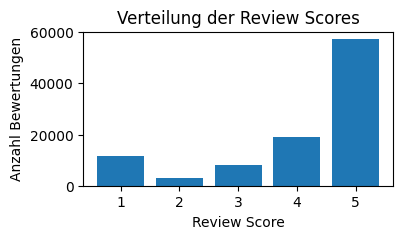

In [81]:
import matplotlib.pyplot as plt

# Verteilung der Review Scores
df_reviews = sql("""
                SELECT
                    review_score,
                    COUNT(*) AS review_count
                FROM order_reviews
                GROUP BY review_score
                ORDER BY review_score
                """)

# Erstellt ein Balkendiagramm der Verteilung der Review Scores
plt.figure(figsize=(4, 2))
plt.bar(df_reviews["review_score"], df_reviews["review_count"])
plt.xlabel("Review Score")
plt.ylabel("Anzahl Bewertungen")
plt.title("Verteilung der Review Scores")
plt.show()

### 6.2 Min, Avg, Max Preise

In [61]:
# Min, Max und Durchschnittspreis der bestellten Artikel
sql("""
    SELECT
        MIN(price) AS min_price,
        MAX(price) AS max_price,
        AVG(price) AS avg_price
    FROM order_items
    """)

,min_price,max_price,avg_price
0,0.85,6735.0,120.653739


### 6.3 Verteilung der Produktpreise

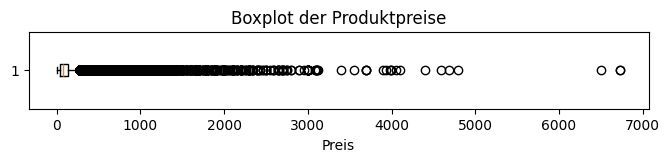

In [90]:
# Verteilung der Produktpreise
df_price = sql("""
                SELECT price
                FROM order_items
                WHERE price IS NOT NULL
                """)

# Verteilung der Produktpreise als Boxplot
plt.figure(figsize=(8,1))
plt.boxplot(df_price["price"], vert = False)
plt.xlabel("Preis")
plt.title("Boxplot der Produktpreise")
plt.show()

### 6.4 Überblick über die Lieferdauer

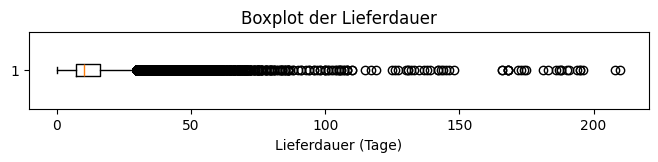

In [87]:
# Berechnet die Lieferdauer in Tagen (nur für tatsächlich ausgelieferte Bestellungen)
df_delivery = sql("""
                  SELECT
                      date_diff('day', order_purchase_timestamp, order_delivered_customer_date) 
                      AS delivery_days
                  FROM orders
                  WHERE order_status = 'delivered'
                    AND order_purchase_timestamp IS NOT NULL
                    AND order_delivered_customer_date IS NOT NULL
                  """)

# Visualisiert die Verteilung der Lieferdauer als Boxplot
plt.figure(figsize=(8,1))
plt.boxplot(df_delivery["delivery_days"], vert = False)
plt.xlabel("Lieferdauer (Tage)")
plt.title("Boxplot der Lieferdauer")
plt.show()

## 7. **Fazit**
Struktur, Beziehungen und Datenqualität des Datensatzes wurden untersucht.

Die Daten bilden die wesentlichen Geschäftsprozesse eines Online-Marketplaces ab
und sind grundsätzlich für eine Analyse geeignet.
Allerdings liegen die Informationen verteilt über mehrere relationale Tabellen vor
und müssen zunächst zu einer auswertbaren Struktur zusammengeführt werden.

Für die weitere Analyse sind daher folgende Schritte erforderlich:

- Zusammenführung der Tabellen auf Bestell- bzw. Kundenebene
- Berechnung von Lieferdauer und Verzögerungsindikatoren
- Aggregation von Zahlungs- und Artikelinformationen
- Ableitung kundenbezogener Kennzahlen

Im nächsten Schritt wird ein analysefähiger Datensatz erstellt.